#### Dataset
- Name: Titanic Dataset
- Task: Binary Classification
- Source: Kaggle
- Reference: Link: https://www.kaggle.com/c/titanic


<h1> Data Processing </h1>

In real-world projects, typically:

A data scientist spends most of their time preparing and understanding the data, rather than building the model.

In machine learning, data is typically represented as:

$$ X \rightarrow y $$

Where:

Features

Model input:

$$ X = \begin{bmatrix} x_1 & x_2 & ... & x_n \end{bmatrix} $$

For example, to predict house prices:

Features:

Area
Number of Rooms
Location
Age
Target

What we want to predict:

$$ y=Price $$

The quality of the final model strongly depends on the quality of the input data.

<h3> Step 1: imports </h3>

In [392]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


<h3> Step 2: dataset </h3>

Titanic.

Problem:</br>
Binary Classification

In [393]:
dataset_path = "../../datasets/Titanic-Dataset/raw/Titanic-Dataset.csv"

df = pd.read_csv(dataset_path)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<h3> Step 3: Initial Dataset Exploration </h3>

Step 3.1: Shape

In [394]:
df.shape

(891, 12)

891 samples
12 features

Step 3.2: Columns Information

In [395]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Numerical:</br>
PassengerId</br>
Survived</br>
Pclass</br>
Age</br>
SibSp</br>
Parch</br>
Fare

Categorical:</br>
Name</br>
Sex</br>
Ticket</br>
Cabin</br>
Embarked

Step 3.3: Descriptive statistics

In [396]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Step 3.4: Missing Values Checking

In [397]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age        177
Cabin      687
Embarked     2

Missing Data

Three important cases:

1) MCAR</br>
Missing Completely At Random

Example:</br>
Random failure of the data recording system.

2) MAR</br>
Missing At Random</br>
Dependent on other attributes.

3) MNAR</br>
Missing Not At Random</br>
The missing value itself contains information.

Step 3.5: Visual Exploration

We’ll have a full EDA later, but here’s a brief overview.

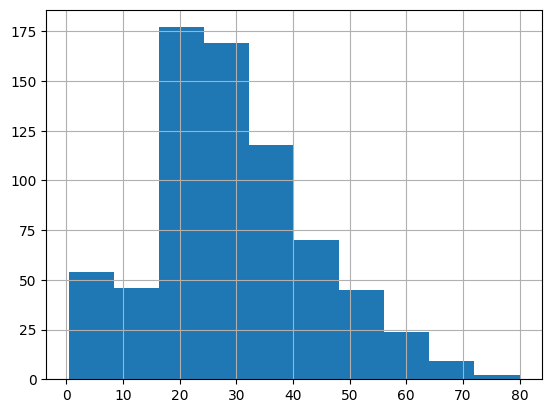

In [398]:
df["Age"].hist()
plt.show()

In [399]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<h3> Step 4: Feature Selection </h3>

The original dataset contains several features, but not all of them are directly suitable for machine learning models.

The following columns are removed temporarily:

- **PassengerId**:
  A unique identifier without predictive information.

- **Name**:
  Raw text data that requires feature extraction before usage.

- **Ticket**:
  Raw categorical information that requires transformation.

- **Cabin**:
  Contains many missing values and requires feature engineering.

The remaining features are:

- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

Advanced feature extraction from removed columns will be explored later in the Feature Engineering section.

In [400]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features].copy()
y = df["Survived"].copy()

In [401]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [402]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [403]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

<h3> Step 5: Train Test Split </h3>

Correct sequence in ML:

Incorrect:

Fill Missing</br>
Scale</br>
Split

Because it causes data leakage.

Correct:

Split

Train:</br>
fit preprocessing

Test:</br>
transform only

For example, the median should be learned only from the training set,
not the entire dataset.

If a simple random split is used, the proportions may change, so we use **stratify=y**.

In [404]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [405]:
print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


In [406]:
print(
    y_train.value_counts(normalize=True)
)

print(
    y_test.value_counts(normalize=True)
)

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


<h3> Step 6: Missing Values ​​After Split </h3>

To prevent data leakage, we transfer statistical information from the training set to the test set. Because in the real world, Test is the future data and we only use the training data before seeing them.

The test set must remain unseen during training.
All preprocessing parameters (such as mean, median, and scaling values) are learned from the training data and then applied to the test data.

Numerical Imputation

In [407]:
age_median = X_train["Age"].median()

age_median

28.5

In [408]:
X_train["Age"] = X_train["Age"].fillna(age_median)

X_test["Age"] = X_test["Age"].fillna(age_median)

Categorical Imputation

In [409]:
embarked_mode = X_train["Embarked"].mode()[0]

embarked_mode

'S'

In [410]:
X_train["Embarked"] = (
    X_train["Embarked"]
    .fillna(embarked_mode)
)

X_test["Embarked"] = (
    X_test["Embarked"]
    .fillna(embarked_mode)
)

In [411]:
X_train.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

<h3> Step 7: Encoding </h3>

Step 7.1: Separating numerical and categorical variables

In [412]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

Step 7.2: Encoding with OneHotEncoder

`drop_first=True` drops one column from each category.

To avoid The Dummy Variable Trap</br>
—that is, perfect correlation between the columns.

Never apply One-Hot Encoding to X_train and X_test separately.
Fit an encoder on X_train, and simply apply (transform) that same encoder to X_test.

The encoder is fitted only on the training data; the test data is only transformed.

In [413]:
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

encoder.fit(
    X_train[categorical_features]
)

X_train_encoded = encoder.transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

Step 7.3: Converting sparse to array

Since OneHotEncoder produces sparse output:

In [414]:
X_train_encoded = X_train_encoded.toarray()

X_test_encoded = X_test_encoded.toarray()

Step 7.4: Obtaining numerical data

In [415]:
X_train_numeric = X_train[numeric_features].values

X_test_numeric = X_test[numeric_features].values

Step 7.5: Feature Combination

In [416]:
X_train_processed = np.hstack(
    [
        X_train_numeric,
        X_train_encoded
    ]
)

X_test_processed = np.hstack(
    [
        X_test_numeric,
        X_test_encoded
    ]
)

In [417]:
encoded_feature_names = (
    encoder.get_feature_names_out(
        categorical_features
    )
)

final_feature_names = (
    numeric_features
    +
    list(encoded_feature_names)
)

final_feature_names

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex_male',
 'Embarked_Q',
 'Embarked_S']

In [418]:
X_train_processed.shape

(712, 8)

<h3> Step 8: Scaling </h3>

Subsequently, models such as Logistic Regression, KNN, and SVM are sensitive to scaling.

StandardScaler standardizes every numeric feature; That is, it converts the values so that approximately:

$$ \text{mean}=0 $$

and

$$ \text{std}=1 $$

The formula for each amount is this:

$$ z=\frac{x-\mu}{\sigma} $$

where:

$x$ = original value </br>
$\mu$ = mean of the same column</br>
$\sigma$ = standard deviation of the same column</br>
$z$ = new scaled value


scaler.fit(X_train)

Here, the scaler learns the following for each column of X_train:

mean</br>
standard deviation

In [419]:
scaler = StandardScaler()

scaler.fit(
    X_train_processed
)

StandardScaler()

A crucial point regarding the test set:

We should not write:

scaler.fit(X_test)

Because this causes data leakage and scaling inconsistency.

In [420]:
print(scaler.mean_)
print(scaler.scale_)

[ 2.30898876 29.55606742  0.49297753  0.39044944 31.81982626  0.64466292
  0.07724719  0.72752809]
[ 0.83297766 13.01612245  1.05997462  0.83754512 48.02534305  0.47861534
  0.26698326  0.44523136]


Then it applies the formula:

$$ \frac{x-\mu_{train}}{\sigma_{train}} $$

In [421]:
X_train_scaled = scaler.transform(
    X_train_processed
)

X_test_scaled = scaler.transform(
    X_test_processed
)

So, our final outputs are:

X_train_scaled</br>
X_test_scaled

y_train</br>
y_test

...which are ready to be fed into the model.

In [422]:
print("X_train_processed.shape:", X_train_processed.shape)
print("X_test_processed.shape: ", X_test_processed.shape)

X_train_scaled[:5]

X_train_processed.shape: (712, 8)
X_test_processed.shape:  (179, 8)


array([[ 0.82956755, -0.08113533, -0.46508428, -0.46618317,  0.5138115 ,
         0.74242727, -0.28933346,  0.61197825],
       [-0.37094484, -0.08113533, -0.46508428, -0.46618317, -0.66256323,
         0.74242727, -0.28933346,  0.61197825],
       [-1.57145722, -0.08113533, -0.46508428, -0.46618317,  3.95539858,
         0.74242727, -0.28933346,  0.61197825],
       [ 0.82956755, -0.88782719, -0.46508428,  0.72778236, -0.46787435,
        -1.34693328, -0.28933346,  0.61197825],
       [-0.37094484,  0.11093416,  0.47833454,  0.72778236, -0.11597681,
        -1.34693328, -0.28933346,  0.61197825]])

In [423]:
print(
    X_train_scaled.mean(axis=0)
)

print(
    X_train_scaled.std(axis=0)
)

[-1.48445550e-16  8.08693000e-17 -1.17259510e-16 -8.57616100e-18
  1.48576142e-15 -2.78803198e-16  6.01266852e-16  2.27969953e-16]
[1. 1. 1. 1. 1. 1. 1. 1.]


In [424]:
encoder.get_feature_names_out(
    categorical_features
)

array(['Sex_male', 'Embarked_Q', 'Embarked_S'], dtype=object)

<h3> Step 9: Standard ColumnTransformer and Pipeline </h3>

A very important point: Since we previously modified the current `X_train` and `X_test` using `fillna()`, it is better to split the raw `X` and `y` again for this part, so that the pipeline can handle the missing values ​​itself.

This means we no longer need to write the following manually:

age_median = ...</br>
fillna(...)</br>
scaler.fit(...)</br>
scaler.transform(...)

The Pipeline itself executes these steps sequentially.

In [425]:
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

#### Making The Structure

Step 9.1: Numerical Pipeline

Missing Value</br>
     ↓</br>
Median</br>
     ↓</br>
StandardScaler

In [426]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

Step 9.2: Categorical Pipeline

Missing Value</br>
     ↓</br>
Most Frequent</br>
     ↓</br>
One Hot Encoding

In [427]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ]
)

Step 9.3: Combining Two Pipelines with ColumnTransformer

In [428]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [429]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Sex', 'Embarked'])])

#### Applying structure to data

Step 9.4: Fit only on Train

The pipeline learns only from the training data:

What is the median?</br>
What is the mode?</br>
What are the mean and standard deviation?</br>
What categories exist?

In [430]:
preprocessor.fit(
    X_train_pipe
)

X_train_pipeline = preprocessor.transform(
    X_train_pipe
)

X_test_pipeline = preprocessor.transform(
    X_test_pipe
)

In [431]:
print(
    "Train shape:",
    X_train_pipeline.shape
)

print(
    "Test shape:",
    X_test_pipeline.shape
)

Train shape: (712, 8)
Test shape: (179, 8)


In [432]:
pipeline_feature_names = (
    preprocessor.get_feature_names_out()
)

pipeline_feature_names

array(['num__Pclass', 'num__Age', 'num__SibSp', 'num__Parch', 'num__Fare',
       'cat__Sex_male', 'cat__Embarked_Q', 'cat__Embarked_S'],
      dtype=object)

Step 9.5: Checking the results

In [433]:
np.isnan(
    np.asarray(X_train_pipeline)
).sum()

0

In [434]:
np.isnan(
    np.asarray(X_test_pipeline)
).sum()

0

In [435]:
X_train_pipeline_df = pd.DataFrame(
    X_train_pipeline,
    columns=pipeline_feature_names,
    index=X_train_pipe.index
)

X_train_pipeline_df.head()

,num__Pclass,num__Age,num__SibSp,num__Parch,num__Fare,cat__Sex_male,cat__Embarked_Q,cat__Embarked_S
692,0.829568,-0.081135,-0.465084,-0.466183,0.513812,1.0,0.0,1.0
481,-0.370945,-0.081135,-0.465084,-0.466183,-0.662563,1.0,0.0,1.0
527,-1.571457,-0.081135,-0.465084,-0.466183,3.955399,1.0,0.0,1.0
855,0.829568,-0.887827,-0.465084,0.727782,-0.467874,0.0,0.0,1.0
801,-0.370945,0.110934,0.478335,0.727782,-0.115977,0.0,0.0,1.0


Step 9.6: Saving The CSV Results

In [436]:
X_train_processed_df = pd.DataFrame(
    X_train_pipeline,
    columns=pipeline_feature_names,
    index=X_train_pipe.index
)

X_test_processed_df = pd.DataFrame(
    X_test_pipeline,
    columns=pipeline_feature_names,
    index=X_test_pipe.index
)

In [437]:
train_processed = X_train_processed_df.copy()
train_processed["Survived"] = y_train_pipe.values

test_processed = X_test_processed_df.copy()
test_processed["Survived"] = y_test_pipe.values

In [439]:
train_processed.to_csv(
    "../../datasets/Titanic-Dataset/processed/train_processed.csv",
    index=False
)

test_processed.to_csv(
    "../../datasets/Titanic-Dataset/processed/test_processed.csv",
    index=False
)

#### Manual Preprocessing vs Scikit-learn Pipeline

The preprocessing workflow was implemented in two different ways.

##### Manual Approach

The preprocessing steps were performed individually:

1. Split the dataset into training and testing sets.
2. Calculate missing-value statistics using the training data.
3. Fill missing numerical values using the training median.
4. Fill missing categorical values using the training mode.
5. Fit the categorical encoder using the training data.
6. Transform training and testing data.
7. Combine numerical and encoded features.
8. Apply feature scaling.

This approach is useful for understanding how each preprocessing
operation works internally.

##### Pipeline Approach

The same workflow was implemented using:

- `SimpleImputer`
- `StandardScaler`
- `OneHotEncoder`
- `Pipeline`
- `ColumnTransformer`

The pipeline approach is more suitable for real-world machine
learning projects because it:

- keeps preprocessing steps organized,
- reduces repetitive code,
- ensures consistent transformations,
- reduces the risk of data leakage,
- integrates directly with machine learning models.

#### Data Leakage

Data leakage occurs when information from the test set influences
the model training process.

For example, calculating the median age using the entire dataset
before splitting would allow information from the test set to affect
the training preprocessing.

Incorrect workflow:

Dataset → Imputation → Scaling → Train/Test Split

Correct workflow:

Dataset → Train/Test Split

Training data:
Fit preprocessing parameters

Testing data:
Apply the learned transformations only

We will see this rule very often from now on:

$$ \boxed{\text{Fit on Train, Transform Train and Test}} $$


Do all models require scaling?

This is also very important.

Scaling is important for models that are sensitive to the distances between data points or the magnitudes of coefficients.


| Algorithm              | Scaling               |
| ---------------------- | --------------------- |
| Linear Regression      | Often useful          |
| Logistic Regression    | Recommended           |
| KNN                    | **Very important**    |
| SVM                    | **Very important**    |
| K-Means                | **Very important**    |
| PCA                    | **Usually important** |
| Decision Tree          | Usually unnecessary   |
| Random Forest          | Usually unnecessary   |
| Gradient Boosted Trees | Usually unnecessary   |


For instance, in KNN using Euclidean distance, certain values ​​exert a much greater influence if scaling is not applied.

However, a decision tree does not calculate distances in this way; it simply creates splits, so changing the scale typically does not disrupt the structure of the problem.

### Summary of our preprocessing decisions for Titanic


| Feature     | Type                         | Treatment                   |
| ----------- | ---------------------------- | --------------------------- |
| Pclass      | Numerical/Ordinal            | Scaling                     |
| Age         | Numerical                    | Median Imputation + Scaling |
| SibSp       | Numerical                    | Scaling                     |
| Parch       | Numerical                    | Scaling                     |
| Fare        | Numerical                    | Scaling                     |
| Sex         | Categorical                  | One-Hot Encoding            |
| Embarked    | Categorical                  | Mode Imputation + One-Hot   |
| PassengerId | Identifier                   | Removed                     |
| Name        | High-cardinality text        | Removed for now             |
| Ticket      | High-cardinality categorical | Removed for now             |
| Cabin       | Mostly missing               | Removed for now             |


## Summary

In this notebook, a complete machine learning preprocessing workflow
was developed using the Titanic dataset.

The main steps included:

- identifying numerical and categorical features,
- separating features and target variables,
- splitting data into training and testing sets,
- handling missing numerical and categorical values,
- encoding categorical variables,
- scaling numerical features,
- preventing data leakage,
- implementing preprocessing manually,
- rebuilding the workflow using Scikit-learn pipelines.

The final preprocessing pipeline transforms the original seven
features into eight model-ready numerical features.

A key principle established in this notebook is:

> Preprocessing parameters must be learned only from the training
> data and then applied unchanged to the test data.